## The Wiener Loss
The Wiener Loss defined as:
$$
\mathcal{L}_w = \frac{1}{2} || \mathbf{W} \left( \mathbf v - \mathbf \delta \right)|| ^2
$$
for

$$ \mathbf v \in \mathbb{R}^n \text{,} \quad \mathbf \delta \in \mathbb{R}^n \text{,} \quad \mathbf{W} \in  \mathbb{R}^{n \times n},$$

is expanded to its normal equation form:

$$
\mathcal{L}_w = \frac{1}{2}  \left( \mathbf v - \mathbf \delta \right) ^\top \mathbf{W}^\top \mathbf{W} \left( \mathbf v - \mathbf \delta \right),
$$

where $\mathbf{W}$ is a whitening matrix that decorrelates the residual $\mathbf{r} = \mathbf{v} - \mathbf{\delta}$ to unit variance from covariance defined by $\mathbf \Sigma^{-1} = \mathbf{W}^\top \mathbf{W} $. It can therefore be rewritten as:


$$
\mathcal{L}_w = \frac{1}{2}  \mathbf r ^\top \mathbf{\Sigma}^{-1} \mathbf r,
% \label{eq:residual_form}
$$

which computes the distance between the residual vector and a Gaussian distribution with mean $\mu = \mathbf 0$ and covariance $\mathbf \Sigma$, also known as the Mahalanobis distance.

---
Note:
1) The choice of $\mathbf W$ is arbritary

## Convexity in $\mathbf v$

We notice that the residual form of the loss is quadratic in $\mathbf v$, so its gradient is linear:
$$
\mathbf{{\nabla}}_{\mathbf v} \mathcal{L}_w = \mathbf{\Sigma}^{-1} \frac{\partial \mathbf r}{\partial \mathbf v} = \mathbf{\Sigma}^{-1} \mathbf v
$$

and its Hessian is a constant

$$
\mathbf{{\nabla}}_{\mathbf v} \mathcal{L}_w = \mathbf{\Sigma}^{-1}
$$

- If $\mathbf{\Sigma}^{-1}$ is not symmetric, the **antisymmetric** part does not contribute to the result since for any vector $\mathbf{r}$ and any skew-symmetric matrix $\mathbf A = -\mathbf A^\top$, we always have $\mathbf{r}^\top \mathbf A \mathbf{r} = 0$. We can isolate the symmetric part of $\mathbf{\Sigma}^{-1}$, without loss of generality, through the Toeplitz decomposition:

$$\mathbf{\Sigma}^{-1} \leftarrow \frac{1}{2}(\mathbf{\Sigma}^{-1} + \mathbf{\Sigma}^{-\top}) $$

- If $\mathbf{\Sigma}^{-1}$ is positive definite (PD), the quadratic form is strictly convex, the Hessian is positive definite, and $\mathcal{L}_w$ is a proper weighted least-squares loss, interpretable as a squared Mahalanobis distance.

- If $\mathbf{\Sigma}^{-1}$ is indefinite the quadratic form is still valid algebraically, but the loss is no longer convex. In this case,
$$\exists \,\mathbf v \in \mathbb{R}^n \quad \text{such that} \quad \mathbf v^\top \mathbf{\Sigma}^{-1}\mathbf v < 0 ,$$
meaning $\mathcal{L}_w$ can take negative values, and the optimisation problem has no well-defined global minimum. The function is then neither a norm nor a valid distance measure.

- If $\mathbf{\Sigma}^{-1}$ is positive semidefinite (PSD), such that:

$$ \mathbf v^\top \mathbf{\Sigma}^{-1}\mathbf v \geq 0 \quad \text{for} \quad \forall \, \mathbf v \in \mathbb{R}^n, $$

 the loss is convex but may be flat in some directions (the Hessian has zero eigenvalues). In such case, $\mathbf{\Sigma}^{-1}$ is not invertible, then $\mathbf \Sigma = \left(\mathbf{\Sigma}^{-1} \right)^{-1}$ would not exist as a proper inverse, and is not a valid covariance matrix.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [85]:
def get_symmetric_part(A):
    return (A + A.T) / 2

def get_sigma_inv_from_W(W):
    return W.T @ W

def get_sigma_from_W(W):
    sigma_inv = get_sigma_inv_from_W(W)
    try:
        return np.linalg.inv(sigma_inv)
    except np.linalg.LinAlgError:
        return None

def check_definite(A, tol=1e-10):
    # Ensure matrix is numpy array
    A = np.array(A, dtype=float)

    # Get only symmetric part
    A = get_symmetric_part(A)

    # Eigenvalues
    eigvals = np.linalg.eigvalsh(A)  # efficient for symmetric matrices
    
    # Tolerance for numerical precision
    tol = 1e-10
    pos = np.all(eigvals > tol)
    nonneg = np.all(eigvals >= -tol)
    neg = np.all(eigvals < -tol)
    nonpos = np.all(eigvals <= tol)
    
    if pos:
        return "positive_definite"
    elif nonneg:
        return "positive_semidefinite"
    elif neg:
        return "negative_definite"
    elif nonpos:
        return "negative_semidefinite"
    else:
        return "indefinite"

### Looking at A in 2D

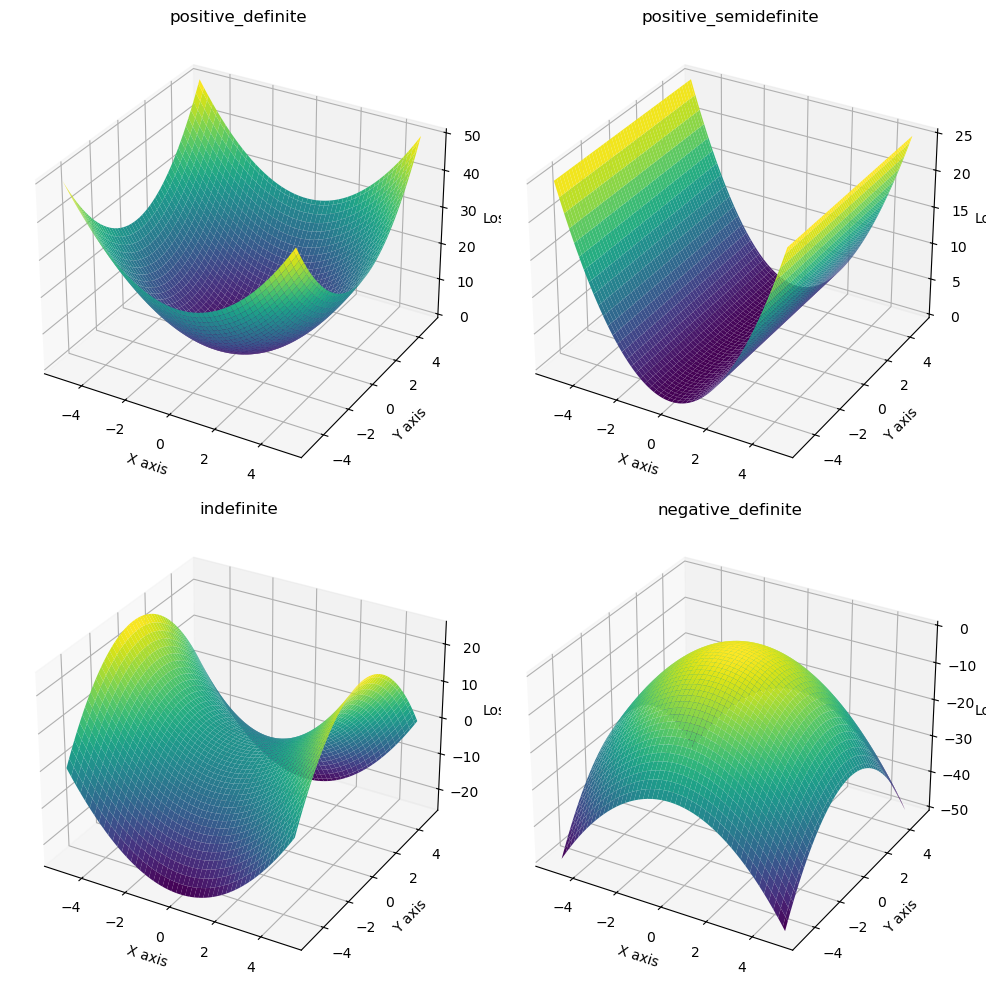

In [13]:
def plot_function_3d(A, b=None, c=None, xlim=(-5, 5), ylim=(-5, 5), num_points=100, ax=None, title=""):
    # Create grid
    x = np.linspace(xlim[0], xlim[1], num_points)
    y = np.linspace(ylim[0], ylim[1], num_points)
    X, Y = np.meshgrid(x, y)

    # Create null b and c if not provided
    n = A.shape[0]
    b = np.zeros(n) if b is None else b
    c = 0 if c is None else c

    # Compute Z values
    Z = np.zeros_like(X)
    for i in range(num_points):
        for j in range(num_points):
            vec = np.array([X[i, j], Y[i, j]])
            Z[i, j] = vec.T @ A @ vec + b.T @ vec + c

    # Plotting
    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis')
    ax.set_xlabel('X axis')
    ax.set_ylabel('Y axis')
    ax.set_zlabel('Loss')
    ax.set_title(title)
    if ax is None:
        plt.show()


# make 4 subplot axes 2x2
fig, axs = plt.subplots(2, 2, subplot_kw={'projection': '3d'}, figsize=(10, 10))
axs = axs.flatten()

A = np.eye(2)
plot_function_3d(A, ax=axs[0], title=check_definite(A))

# A is positive semidefinite
A = np.array([[1, 0], [0, 0]])
plot_function_3d(A, ax=axs[1], title=check_definite(A))

# A is indefinite
A = np.array([[1, 0], [0, -1]])
plot_function_3d(A, ax=axs[2], title=check_definite(A))
# A is negative definite
A = -np.eye(2)
plot_function_3d(A, ax=axs[3], title=check_definite(A))

plt.tight_layout()
plt.show()

### Looking at $W$ and $\Sigma^{-1}$ in $n$-Dimensions

In [93]:
def plot_function_3d_in_projection(A, dir_x, dir_y, b=None, c=None, xlim=(-5, 5), ylim=(-5, 5), num_points=100, ax=None, title=""):
    # Create grid
    x = np.linspace(xlim[0], xlim[1], num_points)
    y = np.linspace(ylim[0], ylim[1], num_points)
    X, Y = np.meshgrid(x, y)

    # Create null b and c if not provided
    n = A.shape[0]
    b = np.zeros(n) if b is None else b
    c = 0 if c is None else c

    # Compute Z values
    Z = np.zeros_like(X)
    for i in range(num_points):
        for j in range(num_points):
            # vec = np.array([X[i, j], Y[i, j]])
            vec = X[i, j] * dir_x + Y[i, j] * dir_y
            Z[i, j] = vec.T @ A @ vec + b.T @ vec + c


    # Plotting
    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis')
    ax.set_xlabel('X axis projection')
    ax.set_ylabel('Y axis projection')
    ax.set_zlabel('Loss')
    ax.set_title(title)
    if ax is None:
        plt.show()

def plot_w(W, ax=None):
    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
    ax.imshow(W, cmap='seismic', vmin=-np.max(np.abs(W)), vmax=np.max(np.abs(W)))
    ax.set_title(r"$W$ (" + check_definite(W) + ")")
    if ax is None:
        plt.show()

Angle between dir_x and dir_y: 88.47765337984292 degrees


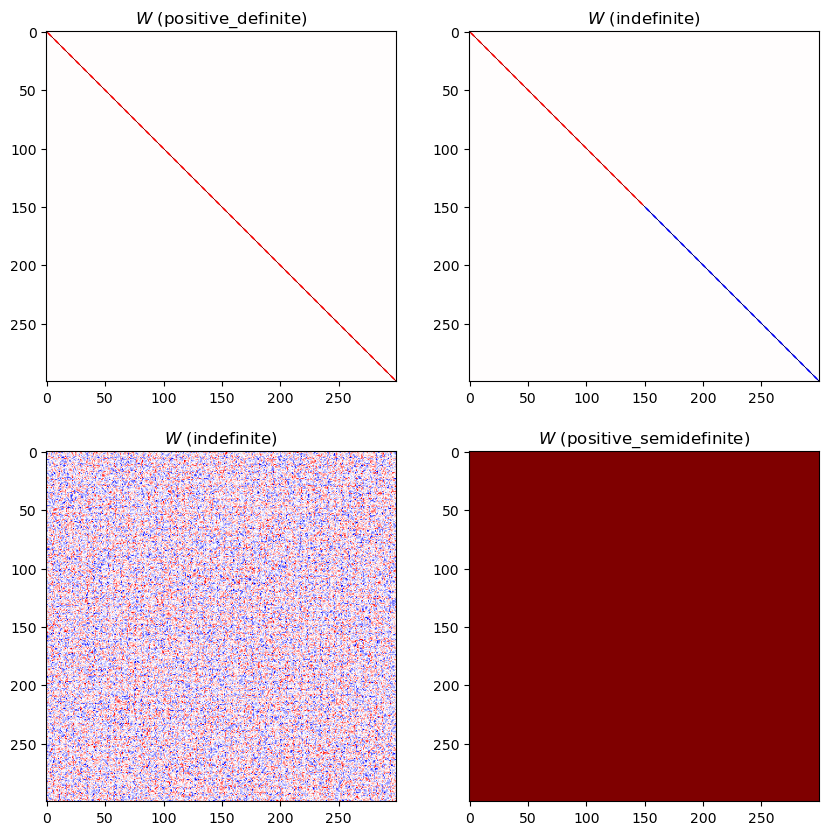

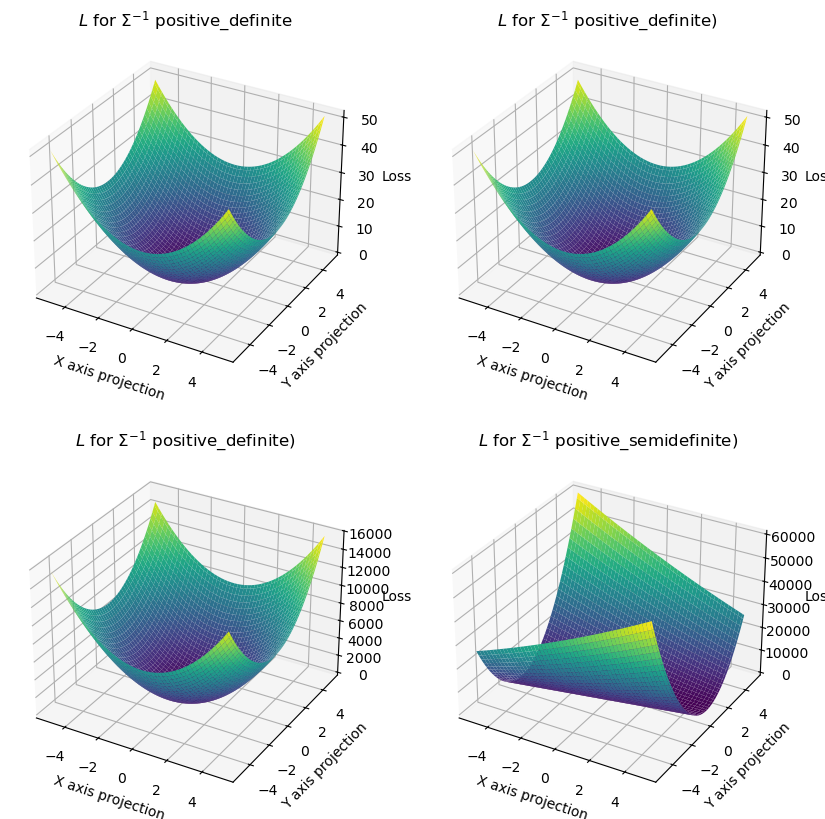

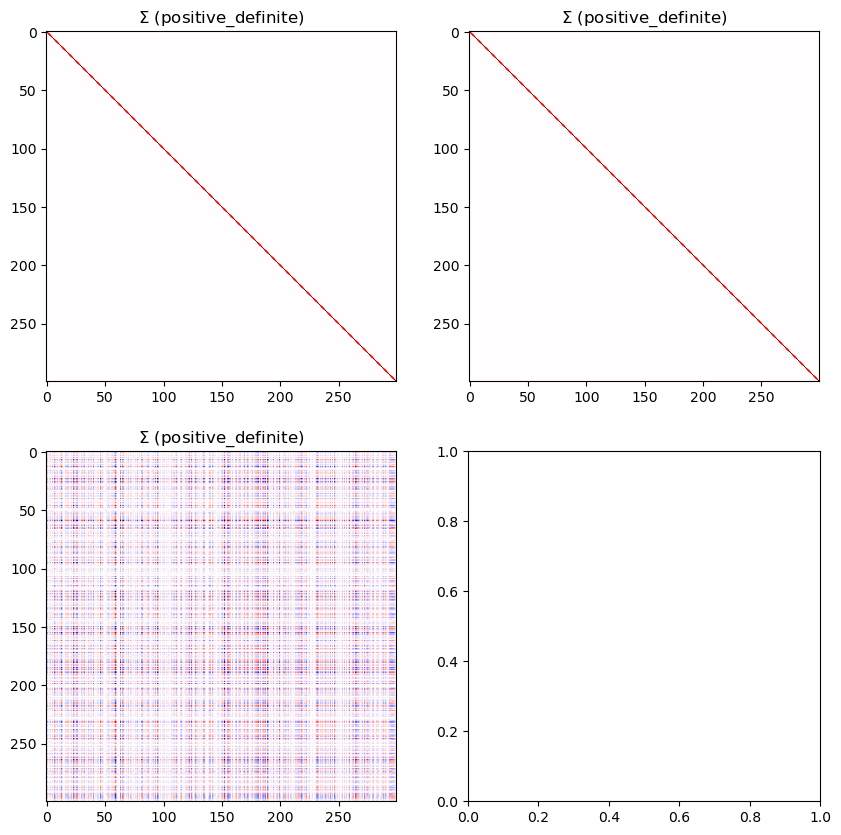

In [92]:
n = 300

# random direction in R^n
np.random.seed(0)
dir_x = np.random.randn(n)
dir_x /= np.linalg.norm(dir_x)
dir_y = np.random.randn(n)
dir_y /= np.linalg.norm(dir_y)

# check angle between dir_x and dir_y
angle = np.arccos(np.clip(np.dot(dir_x, dir_y), -1.0, 1.0))
print(f"Angle between dir_x and dir_y: {np.degrees(angle)} degrees")

# make 4 subplot axes 2x2, for Sinv and for W
fig, axs_w = plt.subplots(2, 2, figsize=(10, 10))
axs_w = axs_w.flatten()

fig, axs_sinv = plt.subplots(2, 2, subplot_kw={'projection': '3d'}, figsize=(10, 10))
axs_sinv = axs_sinv.flatten()

fig, axs_s = plt.subplots(2, 2, figsize=(10, 10))
axs_s = axs_s.flatten()

# positive definite example
W = np.eye(n)
Sinv = get_sigma_inv_from_W(W)
S = get_sigma_from_W(W)
plot_w(W, ax=axs_w[0])
plot_function_3d_in_projection(Sinv, dir_x, dir_y, ax=axs_sinv[0], xlim=(-5, 5), ylim=(-5, 5), title=r"$L$ for $\Sigma^{-1}$ " + check_definite(Sinv) + ""  )
if S is not None:
    axs_s[0].imshow(S, cmap='seismic', vmin=-np.max(np.abs(S)), vmax=np.max(np.abs(S)))
    axs_s[0].set_title(r"$\Sigma$ (" + check_definite(S) + ")")

# indefinite example
W = np.diag(np.concatenate([np.ones(n//2), -np.ones(n//2)]))
Sinv = get_sigma_inv_from_W(W)
S = get_sigma_from_W(W)
plot_w(W, ax=axs_w[1])
plot_function_3d_in_projection(Sinv, dir_x, dir_y, ax=axs_sinv[1], xlim=(-5, 5), ylim=(-5, 5), title=r"$L$ for $\Sigma^{-1}$ " + check_definite(Sinv) + ")")
if S is not None:
    axs_s[1].imshow(S, cmap='seismic', vmin=-np.max(np.abs(S)), vmax=np.max(np.abs(S)))
    axs_s[1].set_title(r"$\Sigma$ (" + check_definite(S) + ")")

W = np.random.randn(n, n)
Sinv = get_sigma_inv_from_W(W)
S = get_sigma_from_W(W)
plot_w(W, ax=axs_w[2])
plot_function_3d_in_projection(Sinv, dir_x, dir_y, ax=axs_sinv[2], xlim=(-5, 5), ylim=(-5, 5), title=r"$L$ for $\Sigma^{-1}$ " + check_definite(Sinv) + ")")
if S is not None:
    axs_s[2].imshow(S, cmap='seismic', vmin=-np.max(np.abs(S)), vmax=np.max(np.abs(S)))
    axs_s[2].set_title(r"$\Sigma$ (" + check_definite(S) + ")")

W = np.ones((n, n))
Sinv = get_sigma_inv_from_W(W)
S = get_sigma_from_W(W)
plot_w(W, ax=axs_w[3])
plot_function_3d_in_projection(Sinv, dir_x, dir_y, ax=axs_sinv[3], xlim=(-5, 5), ylim=(-5, 5), title=r"$L$ for $\Sigma^{-1}$ " + check_definite(Sinv) + ")")
if S is not None:
    axs_s[3].imshow(S, cmap='seismic', vmin=-np.max(np.abs(S)), vmax=np.max(np.abs(S)))
    axs_s[3].set_title(r"$\Sigma$ (" + check_definite(S) + ")")

The above holds when W is a **whitening** matrix and operates on the residuals as a matrix multiplication. However, in current form we apply W as a **penalty matrix** through the Hadamard product.

The **penalty matrix** only has a surrogate matrix multiplication in extremely few cases.


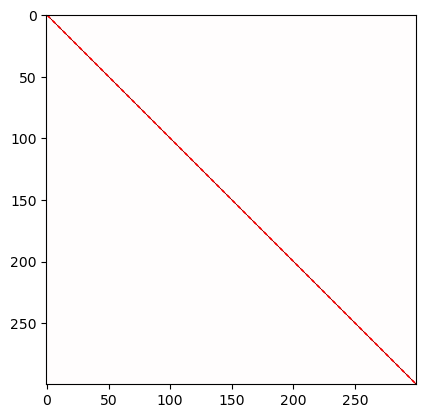

Whitening to hadamard succeeded: W@x == H*x for random x


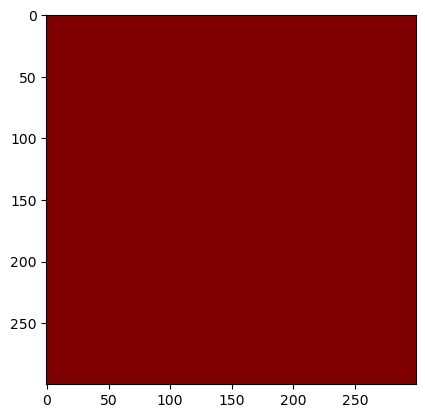

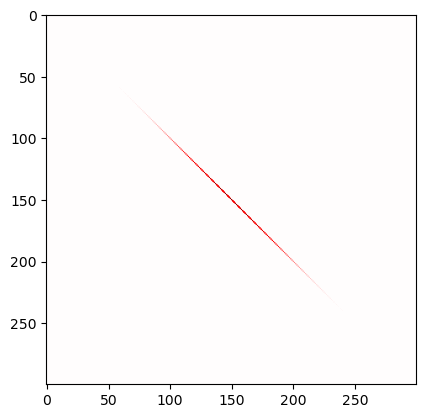

Whitening to hadamard failed: W@x != H*x for random x


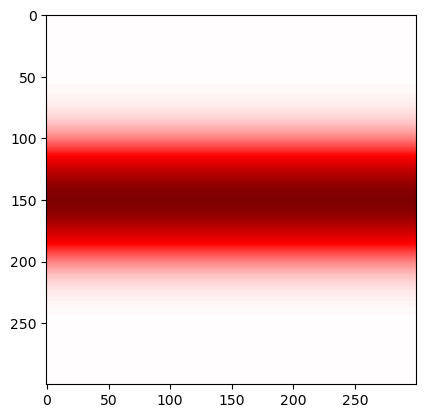

In [83]:
def whitening_to_hadamard(W):
    # assert W is a diagonal matrix
    # assert np.all(W == np.diag(np.diag(W))), "W must be a diagonal matrix, otherwise whitening to hadamard is not defined"
    H = np.empty_like(W)
    for i in range(H.shape[0]):
        H[i] = W[i, i]
    
    vec = np.random.randn(H.shape[0])
    if not np.allclose(W@vec, H*vec):
        print("Whitening to hadamard failed: W@x != H*x for random x")
    else:
        print("Whitening to hadamard succeeded: W@x == H*x for random x")
    return H


# identity
w_diag = np.ones(n)

W = np.diag(w_diag)
# W = np.random.randn(n, n)
plt.imshow(W, cmap='seismic', vmin=-np.max(np.abs(W)), vmax=np.max(np.abs(W)))
plt.show()

H = whitening_to_hadamard(W)
plt.imshow(H, cmap='seismic', vmin=-np.max(np.abs(H)), vmax=np.max(np.abs(H)))
plt.show()
            

# it's now a gaussian function
w_diag = np.exp(-0.5 * ((np.arange(n) - n//2) / (0.1*n))**2)

W = np.diag(w_diag)
# W = np.random.randn(n, n)
plt.imshow(W, cmap='seismic', vmin=-np.max(np.abs(W)), vmax=np.max(np.abs(W)))
plt.show()

H = whitening_to_hadamard(W)
plt.imshow(H, cmap='seismic', vmin=-np.max(np.abs(H)), vmax=np.max(np.abs(H)))
plt.show()

**It is possible that all of the above interpretation, including the normal equation, is not a true reflection of the code implementation!**

**The equations above are true in the 1D case when $W$ is the diagonal matrix (matrix-vec mult) constructed from the penalty $T$ (hamardard mult). But in the 2D case the above is not true.**